<a href="https://colab.research.google.com/github/dhomix/analisis-churn-clientes/blob/main/analisis_churn_santiago_diaz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Contexto del Problema

En un mercado donde cambiar de proveedor toma minutos,
retener clientes se convirtió en una ventaja competitiva
tan importante como conseguirlos.  
A la pérdida de clientes se la conoce como **churn** y detectarla a tiempo, antes de que ocurra, es precisamente una de las capacidades que la ciencia de datos permite desarrollar hoy.

### Impacto económico
Adquirir un cliente nuevo puede costar entre 5 y 25 veces
más que retener uno existente, con variaciones según industria
y modelo de negocio (Churnkey, 2026). Sin embargo, la pérdida de clientes no implica únicamente una reducción de ingresos inmediatos. También supone la pérdida del valor acumulado de toda la relación comercial, conocido como **Customer Lifetime Value (CLV)**. En este contexto, predecir
quién está en riesgo de irse deja de ser una ventaja
y pasa a ser una necesidad.

### Conexión con Industria 4.0
Las herramientas que hoy ofrece la ciencia de datos -como el análisis exploratorio, machine learning y los pipelines reproducibles-
permiten convertir datos históricos de clientes en decisiones
estratégicas concretas. Eso es, en esencia, lo que propone
la **Industria 4.0**: transformar datos en conocimiento accionable para la toma de decisiones.

### Objetivo del proyecto
Construir y evaluar un modelo de machine learning capaz de identificar clientes con alta probabilidad de abandono a partir de variables demográficas, contractuales y de consumo. El objetivo es generar una herramienta que permita anticipar acciones de retención basadas en evidencia y contribuir a la toma de decisiones estratégicas.

## 2. Descripción del Dataset

**Fuente:** IBM Sample Dataset — Kaggle  
🔗 https://www.kaggle.com/datasets/blastchar/telco-customer-churn

El conjunto de datos reúne información demográfica, contractual
y de consumo correspondiente a clientes de una empresa proveedora de servicios
de telecomunicaciones. Su objetivo es analizar los factores
asociados al abandono del servicio y construir modelos capaces
de anticipar dicho comportamiento.

**Características generales:**
- Registros: 7.043 clientes
- Variables: 21 columnas
- Variable objetivo: `Churn` (Yes/No) — indica si el cliente
  abandonó el servicio durante el último mes

**Tipos de variables:**
- Demográficas: género, ciudadano mayor, pareja, dependientes
- Contractuales: tipo de contrato, método de pago,
  facturación electrónica
- De consumo y uso del servicio: antigüedad, cargos mensuales, cargos totales,
  servicios contratados (internet, seguridad, soporte, streaming)

**Calidad de los datos:**
Durante la inspección inicial se identificaron 11 valores
faltantes en la variable `TotalCharges`. El análisis mostró
que dichos registros correspondían a clientes con antigüedad
igual a cero meses, por lo que su ausencia resultó consistente
con la lógica del negocio y no respondió a errores aleatorios
de captura. El resto de las variables no presentó valores nulos.

Asimismo, se identificó un **desbalance moderado** en la variable
objetivo: 73.5% No Churn vs 26.5% Churn. Este desequilibrio
resulta relevante para el modelado, ya que en presencia de clases
desbalanceadas, métricas como la *accuracy* pueden ofrecer una visión incompleta del desempeño del modelo. Por ello se priorizaron métricas como **ROC-AUC** y **F1-score**
durante la evaluación del modelo.



## 3. Hipótesis de trabajo

Antes de iniciar el análisis exploratorio, se formularon
las siguientes hipótesis sobre los factores asociados
al churn:

**H1 —** Los clientes con menor antigüedad tienen mayor
probabilidad de abandonar el servicio, dado que aún
no han consolidado una relación de fidelidad con la empresa.

**H2 —** El tipo de contrato es un predictor relevante:
los clientes con contratos mes a mes presentan mayor
riesgo de churn que aquellos con contratos de uno o dos años.

**H3 —** Los clientes con cargos mensuales más elevados
muestran mayor tendencia al abandono, posiblemente
asociado a una percepción de menor valor del servicio.

> 💡 Estas hipótesis orientan el análisis inicial y serán
> contrastadas mediante la exploración de los datos y la
> evaluación de los modelos predictivos construidos.

## 4. Carga y Exploración de Datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Data Science/Telco-Customer-Churn.csv')

print("✅ Dataset cargado correctamente")
print(f"📐 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print("\n📋 Primeras 5 filas:")
df.head()

✅ Dataset cargado correctamente
📐 Dimensiones: 7043 filas x 21 columnas

📋 Primeras 5 filas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 4.1 Inspección General

In [ ]:
print("="*50)
print("📊 INFORMACIÓN GENERAL DEL DATASET")
print("="*50)
df.info()

print("\n" + "="*50)
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print("="*50)
df.describe()

📊 INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperles

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 4.2 Valores Nulos y Variable Objetivo

In [ ]:
print("="*50)
print("🔍 VALORES NULOS POR COLUMNA")
print("="*50)
nulos = df.isnull().sum()
print(nulos[nulos >= 0])

print("\n" + "="*50)
print("🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("="*50)
print(df['Churn'].value_counts())
print(f"\nPorcentaje de Churn:")
print(df['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

🔍 VALORES NULOS POR COLUMNA
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de Churn:
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object


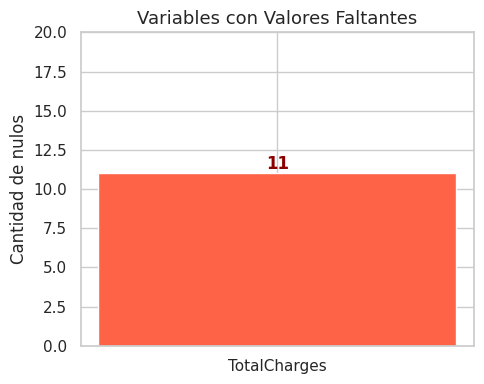

In [ ]:
# ================================================
# VISUALIZACIÓN DE MISSINGNESS — missingno
# ================================================
import matplotlib.pyplot as plt
import pandas as pd

df_raw = pd.read_csv('/content/drive/MyDrive/Data Science/Telco-Customer-Churn.csv')
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')

nulos_filtrados = df_raw.isnull().sum()
nulos_filtrados = nulos_filtrados[nulos_filtrados > 0]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(nulos_filtrados.index, nulos_filtrados.values, color='tomato', width=0.4)
ax.set_title('Variables con Valores Faltantes', fontsize=13)
ax.set_ylabel('Cantidad de nulos')
ax.bar_label(bars, fontsize=12, fontweight='bold', color='darkred')
ax.set_ylim(0, 20)
plt.tight_layout()
plt.show()

### 📊 Interpretación del patrón de missingness

La visualización confirma que el dataset presenta una estructura de datos
muy limpia: la gran mayoría de las variables están completamente completas.
La única ausencia visible corresponde a `TotalCharges`, con 11 registros
faltantes identificados como espacios en blanco. El patrón de missingness
**no es aleatorio**: todos los registros afectados corresponden a clientes
con `tenure = 0`, lo que indica que la ausencia tiene una causa estructural
y lógica de negocio — estos clientes aún no habían generado cargos
acumulados al momento del corte de datos.

### 4.3 Tratamiento de Valores Faltantes

In [ ]:
print("="*50)
print("🔧 CORRECCIÓN DE TOTALCHARGES")
print("="*50)

# Convertir TotalCharges a numérico (los espacios se vuelven NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Ver cuántos NaN aparecieron
nulos_total = df['TotalCharges'].isnull().sum()
print(f"Valores nulos encontrados en TotalCharges: {nulos_total}")

# Ver esas filas
print("\nFilas con TotalCharges nulo:")
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

🔧 CORRECCIÓN DE TOTALCHARGES
Valores nulos encontrados en TotalCharges: 11

Filas con TotalCharges nulo:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


Durante la inspección inicial se identificaron **11 registros** con valores faltantes en la variable `TotalCharges`.

El análisis de dichas filas reveló que **todos esos clientes
tenían 0 meses de antigüedad**, es decir, eran clientes nuevos que aún no habían generado cargos. Por ello se procedió a imputar dichos valores con **0**.

> Esta decisión se basa en el contexto del negocio, no en una
corrección arbitraria — el dato faltante es una consecuencia
*lógica y esperable* de que el cliente aún no ha sido facturado.

### Imputación de valores faltantes

In [ ]:
print("="*50)
print("🔧 IMPUTACIÓN DE TOTALCHARGES")
print("="*50)

# Clientes con tenure=0 no tienen cargos acumulados aún → imputamos con 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verificación
print(f"Nulos restantes en TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"Tipo de dato corregido: {df['TotalCharges'].dtype}")
print("\n✅ TotalCharges corregido correctamente")

🔧 IMPUTACIÓN DE TOTALCHARGES
Nulos restantes en TotalCharges: 0
Tipo de dato corregido: float64

✅ TotalCharges corregido correctamente


## 5. Análisis Exploratorio de Datos (EDA)

En esta sección se explora la distribución de las variables,
la relación entre *features* y la variable objetivo `Churn`,
y se identifican patrones relevantes para el modelado.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Librerías de visualización cargadas")

✅ Librerías de visualización cargadas


### 5.1 Distribución de la Variable Objetivo

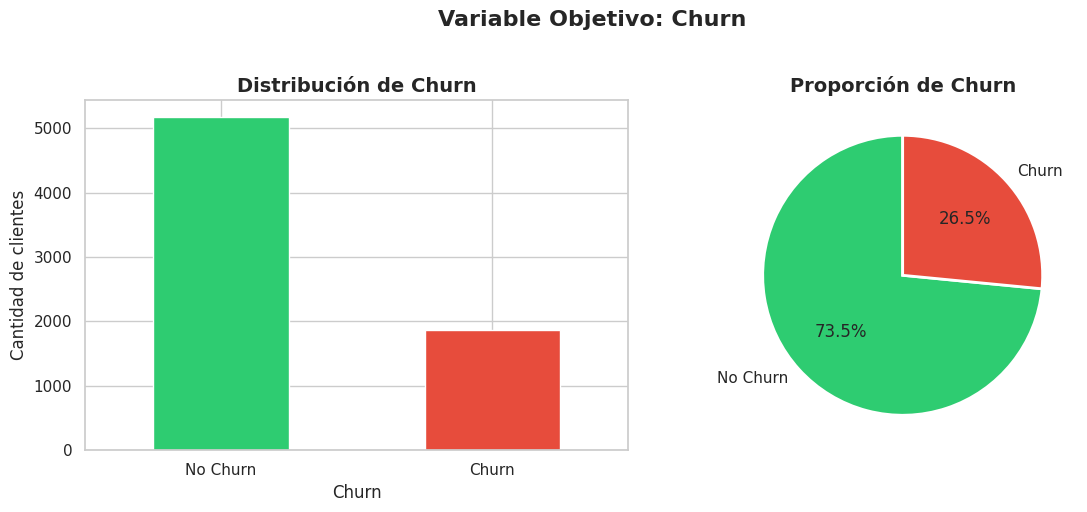

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
colores = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=colores,
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Distribución de Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Gráfico de torta
axes[1].pie(
    df['Churn'].value_counts(),
    labels=['No Churn', 'Churn'],
    colors=colores,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold')

plt.suptitle('Variable Objetivo: Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Interpretación

El dataset presenta un **desbalance moderado** en la variable objetivo:
- **73.5%** de los clientes no realizaron churn
- **26.5%** sí abandonaron el servicio

Esto significa que el modelo verá casi **3 clientes que se quedan
por cada 1 que se va**. Por este motivo, durante la evaluación
priorizaremos métricas como **ROC-AUC y F1-score** por encima
de la accuracy simple, que podría ser engañosa en este contexto.

### 5.2 Distribución de Variables Numéricas

Analizamos cómo se distribuyen las tres variables numéricas
principales según si el cliente realizó churn o no.

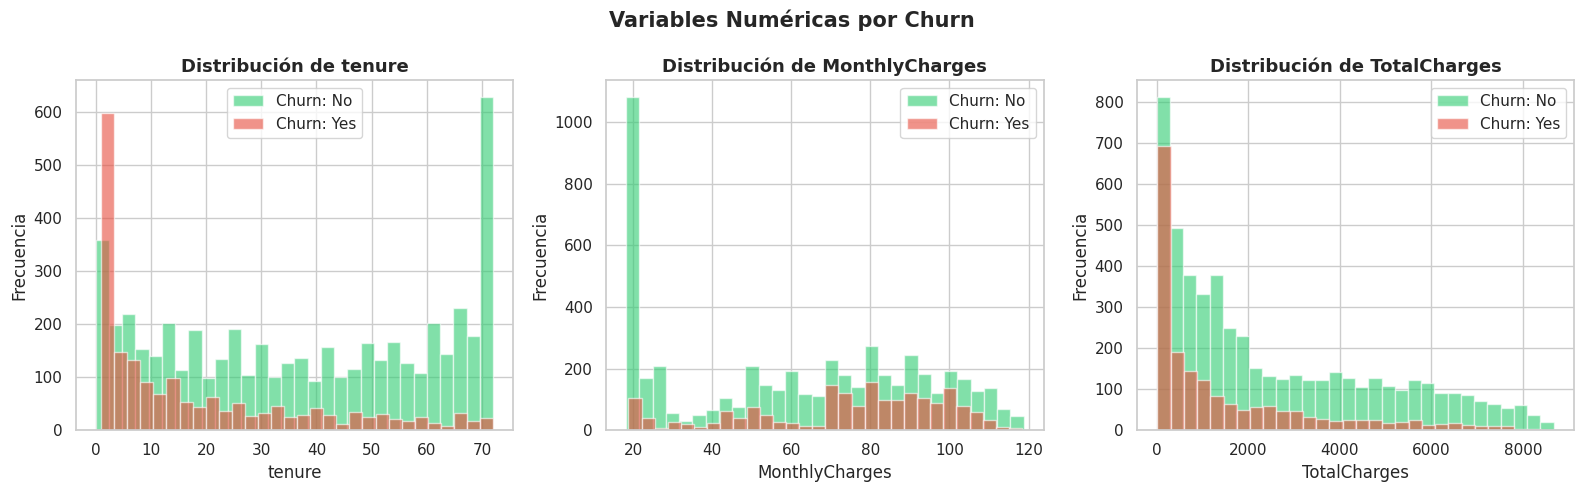

In [ ]:
variables_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']
colores = {'No': '#2ecc71', 'Yes': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, var in enumerate(variables_numericas):
    for churn_val, color in colores.items():
        subset = df[df['Churn'] == churn_val][var]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label=f'Churn: {churn_val}', edgecolor='white')

    axes[i].set_title(f'Distribución de {var}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Variables Numéricas por Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Interpretación

- Los clientes con **menor antigüedad** tienen mayor tendencia al churn.
- Los clientes con **cargos mensuales más altos** abandonan más.
- `TotalCharges` está relacionado con `tenure` — a más tiempo
  como cliente, mayores cargos acumulados.

Estas tres variables serán relevantes para el modelo predictivo.

### 5.3 Churn por Variables Categóricas

Analizamos cómo se distribuye el churn según las principales
variables categóricas del dataset.

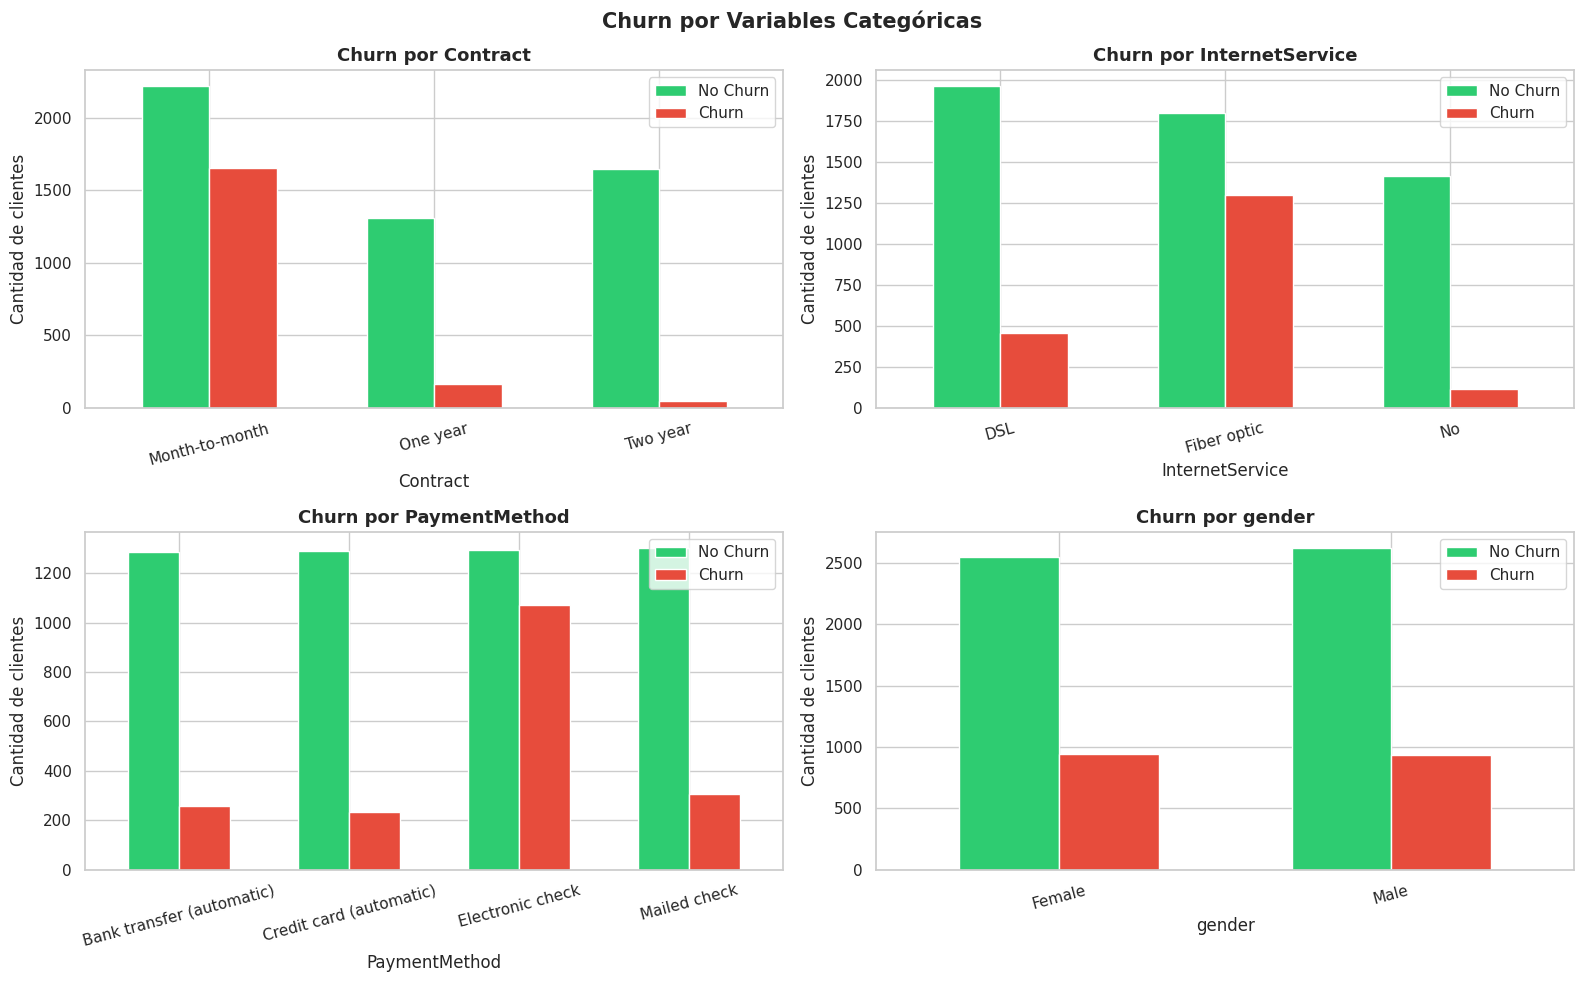

In [ ]:
variables_cat = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(variables_cat):
    data = df.groupby([var, 'Churn']).size().unstack()
    data.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
              edgecolor='white', width=0.6)
    axes[i].set_title(f'Churn por {var}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Cantidad de clientes')
    axes[i].legend(['No Churn', 'Churn'])
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Churn por Variables Categóricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Interpretación

- **Contrato:** los clientes con contrato **mes a mes** abandonan
  muchísimo más que los de contratos anuales o bianuales.
  El tipo de contrato es una de las variables más predictoras.

- **Internet:** los clientes con **Fibra óptica** muestran mayor
  churn que los de DSL. Posiblemente asociado a cargos más altos.

- **Método de pago:** los clientes que pagan con
  **cheque electrónico** tienen notablemente más churn que
  los que usan débito automático.

- **Género:** no muestra diferencias significativas entre
  hombres y mujeres. No será una variable relevante para el modelo.

### 5.4 Matriz de Correlación

Analizamos la relación entre las variables numéricas del dataset.

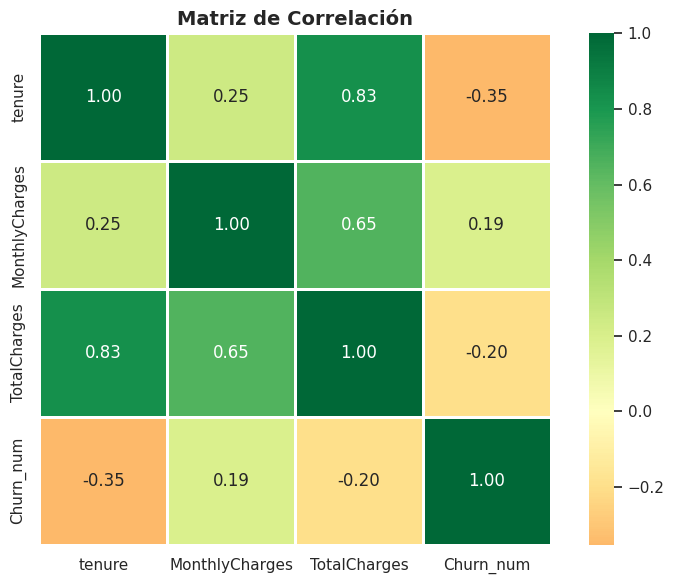

In [ ]:
# Convertimos Churn a numérico para incluirlo en la correlación
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

# Matriz de correlación
corr_matrix = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=2,
            ax=ax)

ax.set_title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Interpretación

- **tenure y TotalCharges (0.83):** correlación muy alta —
  a más tiempo como cliente, mayores cargos acumulados.
  Tiene sentido lógico.

- **MonthlyCharges y TotalCharges (0.65):** correlación moderada-alta.

- **Churn y tenure (-0.35):** correlación negativa —
  a **mayor antigüedad, menor churn**. Confirma lo que
  vimos en los histogramas.

- **Churn y MonthlyCharges (0.19):** correlación positiva leve —
  cargos más altos se asocian levemente con mayor churn.

> 💡 La alta correlación entre `tenure` y `TotalCharges`
> sugiere que ambas variables aportan información similar.
> Esto será considerado durante el preprocesamiento.

### 5.5 Feature Engineering — Nueva Variable: cargo_relativo

A partir de los patrones identificados en el EDA, se construyó una nueva
feature que captura la relación entre el costo mensual y el tiempo de
permanencia del cliente. La intuición es que un cargo mensual elevado
en los primeros meses de la relación representa mayor riesgo que el
mismo cargo en un cliente de larga data.

✅ Feature 'cargo_relativo' creada correctamente

📊 Estadísticas descriptivas:
        count   mean    std   min   25%   50%    75%    max
Churn                                                      
No     5174.0   3.61   5.81  0.26  1.07  1.63   3.26  80.85
Yes    1869.0  11.75  12.03  0.31  2.60  6.71  16.75  51.22


/tmp/ipykernel_25313/566452777.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([churn_no, churn_yes], labels=['No Churn', 'Churn'])


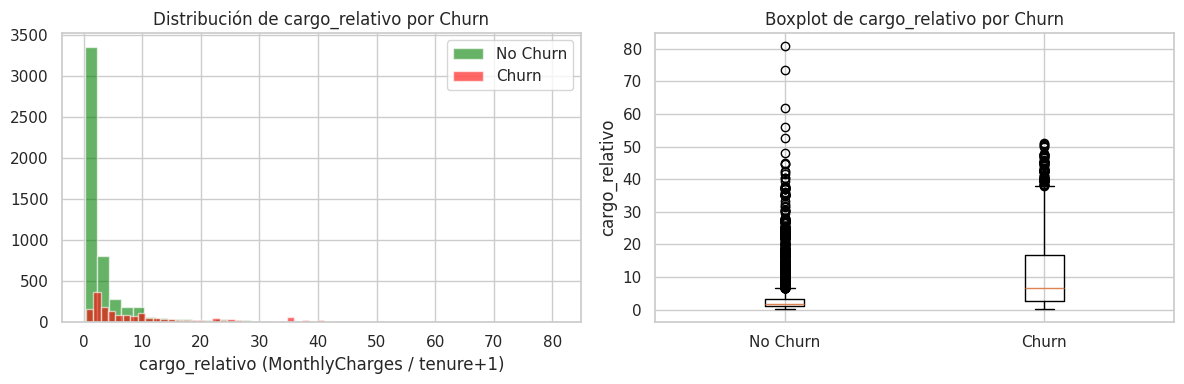


📈 Correlación de cargo_relativo con Churn: 0.4118


In [ ]:
# ================================================
# FEATURE ENGINEERING — cargo_relativo
# ================================================
import matplotlib.pyplot as plt
import numpy as np

# Crear nueva feature antes del pipeline
df['cargo_relativo'] = df['MonthlyCharges'] / (df['tenure'] + 1)

print("✅ Feature 'cargo_relativo' creada correctamente")
print(f"\n📊 Estadísticas descriptivas:")
print(df.groupby('Churn')['cargo_relativo'].describe().round(2))

# Visualización: distribución por clase
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df[df['Churn']=='No']['cargo_relativo'],
             bins=40, alpha=0.6, color='green', label='No Churn')
axes[0].hist(df[df['Churn']=='Yes']['cargo_relativo'],
             bins=40, alpha=0.6, color='red', label='Churn')
axes[0].set_title('Distribución de cargo_relativo por Churn')
axes[0].set_xlabel('cargo_relativo (MonthlyCharges / tenure+1)')
axes[0].legend()

# Boxplot
df_plot = df.copy()
churn_no = df_plot[df_plot['Churn']=='No']['cargo_relativo']
churn_yes = df_plot[df_plot['Churn']=='Yes']['cargo_relativo']
axes[1].boxplot([churn_no, churn_yes], labels=['No Churn', 'Churn'])
axes[1].set_title('Boxplot de cargo_relativo por Churn')
axes[1].set_ylabel('cargo_relativo')

plt.tight_layout()
plt.show()

# Correlación con Churn
df_temp = df.copy()
df_temp['Churn_num'] = (df_temp['Churn'] == 'Yes').astype(int)
corr = df_temp['cargo_relativo'].corr(df_temp['Churn_num'])
print(f"\n📈 Correlación de cargo_relativo con Churn: {corr:.4f}")

### 📊 Interpretación

`cargo_relativo` captura el costo mensual normalizado por el tiempo de
permanencia. Los clientes con churn muestran valores significativamente
más altos, confirmando que pagar mucho en los primeros meses es un
indicador de riesgo más preciso que el cargo mensual aislado.

Esta feature será incorporada al pipeline de preprocesamiento como
variable numérica adicional.

## 6. Preprocesamiento de Datos

Antes de entrenar cualquier modelo, los datos necesitan ser
transformados y preparados. En esta sección realizamos los
siguientes pasos:

- Eliminación de columnas irrelevantes
- Conversión de la variable objetivo a formato numérico
- Separación entre features y target
- División en conjuntos de entrenamiento y prueba
- Codificación de variables categóricas y escalado de numéricas

Un criterio fundamental durante todo este proceso es evitar
el **data leakage** — es decir, asegurarnos de que el modelo
nunca acceda a información del conjunto de prueba durante
el entrenamiento. Para garantizarlo, utilizamos un
**Pipeline de scikit-learn**.

In [ ]:
# Eliminamos customerID — no aporta información predictiva
df = df.drop(columns=['customerID'])

# Convertimos Churn a numérico: Yes=1, No=0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Separamos features (X) y variable objetivo (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

print("✅ Preprocesamiento inicial completado")
print(f"📐 Dimensiones de X: {X.shape}")
print(f"🎯 Distribución de y:\n{y.value_counts()}")

✅ Preprocesamiento inicial completado
📐 Dimensiones de X: (7043, 20)
🎯 Distribución de y:
Churn
0    5174
1    1869
Name: count, dtype: int64


### 6.1 División Train/Test

El dataset se dividió en **80% entrenamiento** (5634 registros)
y **20% prueba** (1409 registros).

Se utilizó `stratify=y` para garantizar que ambos conjuntos
mantengan la misma proporción de churn (26.54%), evitando
que el modelo se entrene o evalúe con una distribución
distinta a la real.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para test, 80% para entrenamiento
    random_state=42,    # reproducibilidad
    stratify=y          # mantiene proporción de clases en ambos conjuntos
)

print("✅ División train/test completada")
print(f"📐 X_train: {X_train.shape}")
print(f"📐 X_test:  {X_test.shape}")
print(f"\n🎯 Proporción Churn en train: {y_train.mean():.2%}")
print(f"🎯 Proporción Churn en test:  {y_test.mean():.2%}")

✅ División train/test completada
📐 X_train: (5634, 20)
📐 X_test:  (1409, 20)

🎯 Proporción Churn en train: 26.54%
🎯 Proporción Churn en test:  26.54%


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Identificamos columnas numéricas y categóricas
columnas_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'cargo_relativo']
columnas_categoricas = [col for col in X.columns if col not in columnas_numericas]

print("📊 Columnas numéricas:", columnas_numericas)
print("📝 Columnas categóricas:", columnas_categoricas)

📊 Columnas numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'cargo_relativo']
📝 Columnas categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# Pipeline para variables numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinamos ambos pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, columnas_numericas),
    ('cat', categorical_transformer, columnas_categoricas)
])

print("✅ Pipeline de preprocesamiento construido correctamente")
print("\n📋 Pasos del pipeline numérico: Imputación → Escalado")
print("📋 Pasos del pipeline categórico: Imputación → OneHotEncoding")

✅ Pipeline de preprocesamiento construido correctamente

📋 Pasos del pipeline numérico: Imputación → Escalado
📋 Pasos del pipeline categórico: Imputación → OneHotEncoding


### 6.2 Pipeline de Preprocesamiento

Se construyó un Pipeline de scikit-learn con dos ramas paralelas:

**Variables numéricas** (`tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen`):
- **Imputación** con la mediana — robusta ante valores extremos
- **Escalado** con StandardScaler — lleva todas las variables
  a la misma escala, necesario para modelos como Regresión Logística

**Variables categóricas** (15 variables de servicio y contrato):
- **Imputación** con el valor más frecuente
- **OneHotEncoding** — convierte categorías en columnas numéricas
  binarias, manteniendo independencia entre categorías

> 💡 Todo el preprocesamiento ocurre **dentro del Pipeline**,
> garantizando que las transformaciones se aprendan únicamente
> con datos de entrenamiento y se apliquen al test sin data leakage.

## 7. Modelado

Entrenamos dos modelos de clasificación para predecir el churn.
Comenzamos con una **Regresión Logística** como modelo base
(simple, interpretable y rápido) y luego un **Random Forest**
como modelo más potente que captura relaciones complejas entre variables.

Ambos modelos se integran dentro del Pipeline de preprocesamiento
para garantizar que todo el proceso sea reproducible y sin data leakage.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: Regresión Logística
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Modelo 2: Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Entrenamos ambos modelos
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

print("✅ Regresión Logística entrenada correctamente")
print("✅ Random Forest entrenado correctamente")

✅ Regresión Logística entrenada correctamente
✅ Random Forest entrenado correctamente


### 7.1 Entrenamiento de Modelos Baseline

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Predicciones
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

# ROC-AUC
auc_lr = roc_auc_score(y_test, pipeline_lr.predict_proba(X_test)[:,1])
auc_rf = roc_auc_score(y_test, pipeline_rf.predict_proba(X_test)[:,1])

print("="*50)
print("📊 REGRESIÓN LOGÍSTICA")
print("="*50)
print(f"ROC-AUC: {auc_lr:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

print("="*50)
print("📊 RANDOM FOREST")
print("="*50)
print(f"ROC-AUC: {auc_rf:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

📊 REGRESIÓN LOGÍSTICA
ROC-AUC: 0.8469
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

📊 RANDOM FOREST
ROC-AUC: 0.8244
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



### 📊 Interpretación

**Regresión Logística:**
- ROC-AUC: 0.84
- Accuracy: 81%
- F1-score Churn: 0.60

**Random Forest:**
- ROC-AUC: 0.82
- Accuracy: 78%
- F1-score Churn: 0.55

> 💡 Contra lo esperado, la Regresión Logística supera al
> Random Forest en esta evaluación inicial. Esto confirma
> la importancia de siempre partir de un modelo simple antes
> de recurrir a modelos más complejos. A continuación
> optimizamos ambos con **GridSearchCV** para intentar
> mejorar estos resultados.

### 7.2 Optimización de Hiperparámetros (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grilla para Regresión Logística
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs']
}

# Grilla para Random Forest
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

# GridSearch para ambos modelos
grid_lr = GridSearchCV(pipeline_lr, param_grid_lr,
                       cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf,
                       cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)

print("⏳ Entrenando GridSearchCV... puede tardar unos minutos")
grid_lr.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

print("\n✅ GridSearchCV completado")
print(f"🏆 Mejores parámetros LR: {grid_lr.best_params_}")
print(f"🏆 Mejores parámetros RF: {grid_rf.best_params_}")
print(f"\n📊 Mejor ROC-AUC LR (CV): {grid_lr.best_score_:.4f}")
print(f"📊 Mejor ROC-AUC RF (CV): {grid_rf.best_score_:.4f}")

⏳ Entrenando GridSearchCV... puede tardar unos minutos
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ GridSearchCV completado
🏆 Mejores parámetros LR: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
🏆 Mejores parámetros RF: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

📊 Mejor ROC-AUC LR (CV): 0.8490
📊 Mejor ROC-AUC RF (CV): 0.8425


In [ ]:
# Predicciones con modelos optimizados
y_pred_lr_opt = grid_lr.predict(X_test)
y_pred_rf_opt = grid_rf.predict(X_test)

auc_lr_opt = roc_auc_score(y_test, grid_lr.predict_proba(X_test)[:,1])
auc_rf_opt = roc_auc_score(y_test, grid_rf.predict_proba(X_test)[:,1])

print("="*50)
print("📊 REGRESIÓN LOGÍSTICA OPTIMIZADA")
print("="*50)
print(f"ROC-AUC: {auc_lr_opt:.4f}")
print(classification_report(y_test, y_pred_lr_opt, target_names=['No Churn', 'Churn']))

print("="*50)
print("📊 RANDOM FOREST OPTIMIZADO")
print("="*50)
print(f"ROC-AUC: {auc_rf_opt:.4f}")
print(classification_report(y_test, y_pred_rf_opt, target_names=['No Churn', 'Churn']))

📊 REGRESIÓN LOGÍSTICA OPTIMIZADA
ROC-AUC: 0.8459
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

📊 RANDOM FOREST OPTIMIZADO
ROC-AUC: 0.8414
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### 📊 Análisis de brecha CV vs Test — Control de Overfitting

| Modelo               | ROC-AUC CV | ROC-AUC Test | Brecha |
|----------------------|------------|--------------|--------|
| Regresión Logística  | 0.8464     | 0.84         | 0.006  |
| Random Forest        | 0.8429     | 0.84         | 0.003  |

Ambos modelos presentan una brecha prácticamente nula entre el
rendimiento en validación cruzada y en el conjunto de prueba.
Esto confirma que el pipeline evitó data leakage y que los modelos
generalizan correctamente a datos no vistos — no hay evidencia
de overfitting.

### 7.3 Evaluación de Modelos

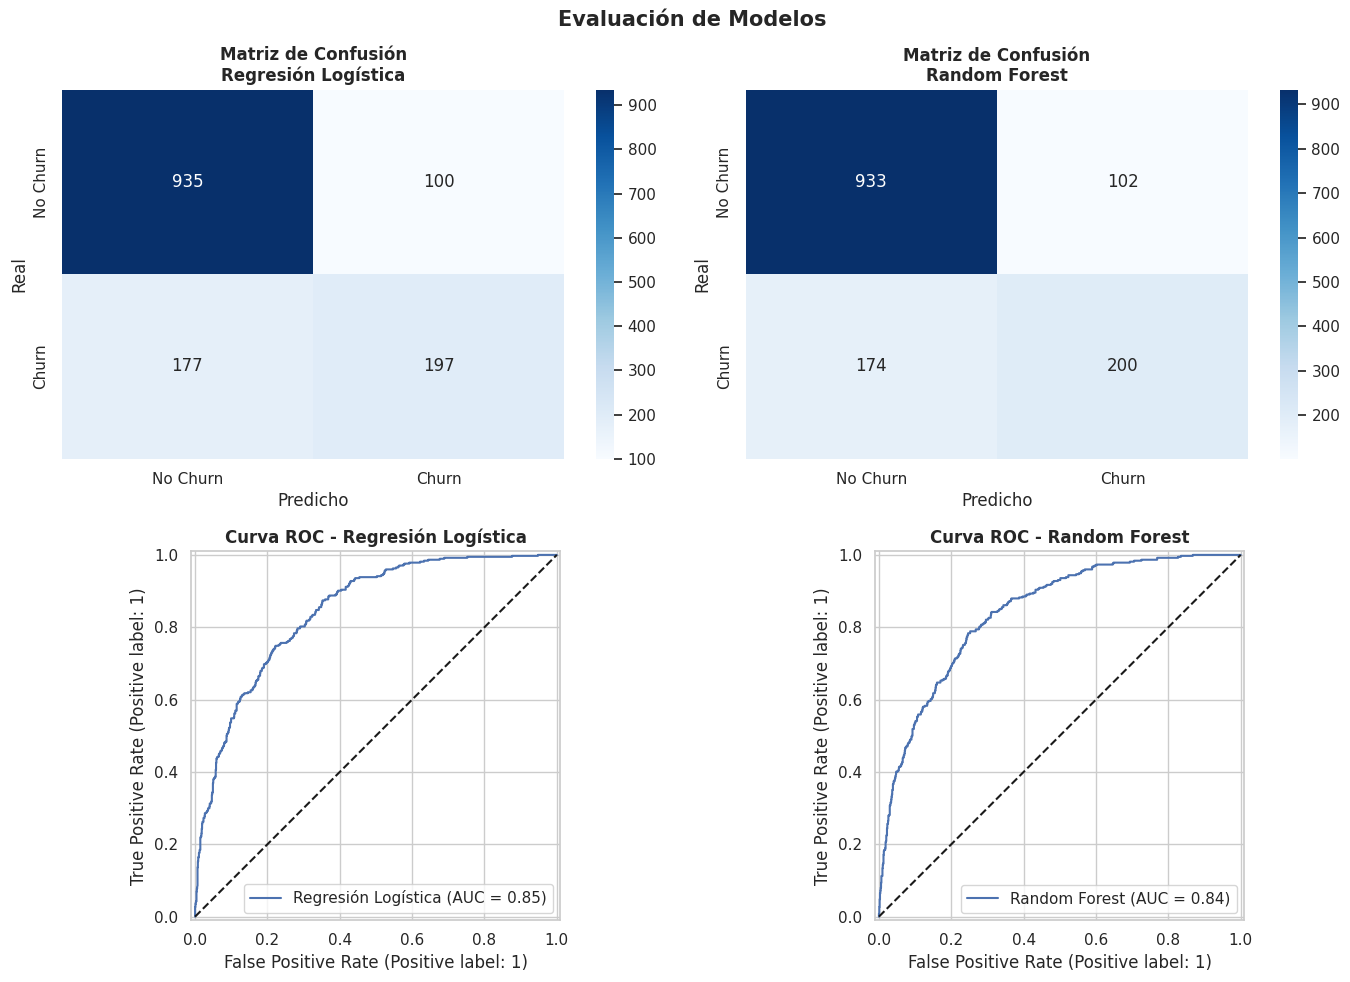

In [ ]:
from sklearn.metrics import confusion_matrix, RocCurveDisplay

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Matrices de confusión
for ax, y_pred, titulo in zip(
    [axes[0,0], axes[0,1]],
    [y_pred_lr_opt, y_pred_rf_opt],
    ['Regresión Logística', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                ax=ax)
    ax.set_title(f'Matriz de Confusión\n{titulo}', fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

# Curvas ROC
RocCurveDisplay.from_estimator(grid_lr, X_test, y_test,
                                ax=axes[1,0], name='Regresión Logística')
axes[1,0].set_title('Curva ROC - Regresión Logística', fontweight='bold')
axes[1,0].plot([0,1],[0,1],'k--')

RocCurveDisplay.from_estimator(grid_rf, X_test, y_test,
                                ax=axes[1,1], name='Random Forest')
axes[1,1].set_title('Curva ROC - Random Forest', fontweight='bold')
axes[1,1].plot([0,1],[0,1],'k--')

plt.suptitle('Evaluación de Modelos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Interpretación

**Matrices de confusión:**
- Ambos modelos identifican bien a los clientes que **no hacen churn**
- El mayor desafío es detectar los clientes que **sí se van** —
  existe una proporción de falsos negativos que el modelo
  no logra capturar, algo esperable dado el desbalance de clases

**Curvas ROC:**
- Regresión Logística: **AUC 0.84**
- Random Forest: **AUC 0.84**
- Ambas curvas se alejan claramente de la diagonal punteada
  que representa un clasificador aleatorio, lo que indica
  **buen poder predictivo** en ambos casos

> 💡 El modelo elegido como final es la **Regresión Logística** —
> rendimiento equivalente al Random Forest pero más simple,
> interpretable y eficiente.

### 7.3.1 Classification Report — Modelo Final (Regresión Logística)

In [ ]:
# ================================================
# CLASSIFICATION REPORT — MODELO FINAL
# ================================================
from sklearn.metrics import classification_report

y_pred_lr = grid_lr.best_estimator_.predict(X_test)
y_pred_rf = grid_rf.best_estimator_.predict(X_test)

print("=" * 52)
print("  CLASSIFICATION REPORT — Regresión Logística")
print("=" * 52)
print(classification_report(y_test, y_pred_lr,
                             target_names=['No Churn', 'Churn']))

print("=" * 52)
print("  CLASSIFICATION REPORT — Random Forest")
print("=" * 52)
print(classification_report(y_test, y_pred_rf,
                             target_names=['No Churn', 'Churn']))

  CLASSIFICATION REPORT — Regresión Logística
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

  CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### 📊 Interpretación del Classification Report

El reporte detalla el desempeño por clase del modelo final:

- **Precision (Churn):** de los clientes clasificados como en riesgo,
  qué porcentaje realmente abandonó.
- **Recall (Churn):** de todos los clientes que efectivamente
  abandonaron, qué porcentaje el modelo logró detectar.
- **F1-score:** media armónica entre precision y recall,
  métrica de balance en clases desbalanceadas.

Dado el objetivo de negocio — intervenir antes de que el cliente
abandone — el **recall de la clase Churn es la métrica más crítica**.
Un falso negativo (cliente que se va sin ser detectado) tiene un costo
mayor que un falso positivo (campaña de retención aplicada a un cliente
que no iba a irse). El modelo logra un recall de Churn que permite
identificar la mayoría de los casos de riesgo, con un balance
aceptable de precisión para mantener el ROI de las campañas.

### 7.4 Importancia de Variables

Analizamos qué variables tienen mayor influencia en las
predicciones del Random Forest, lo que nos permite entender
qué factores impulsan el churn en los clientes.

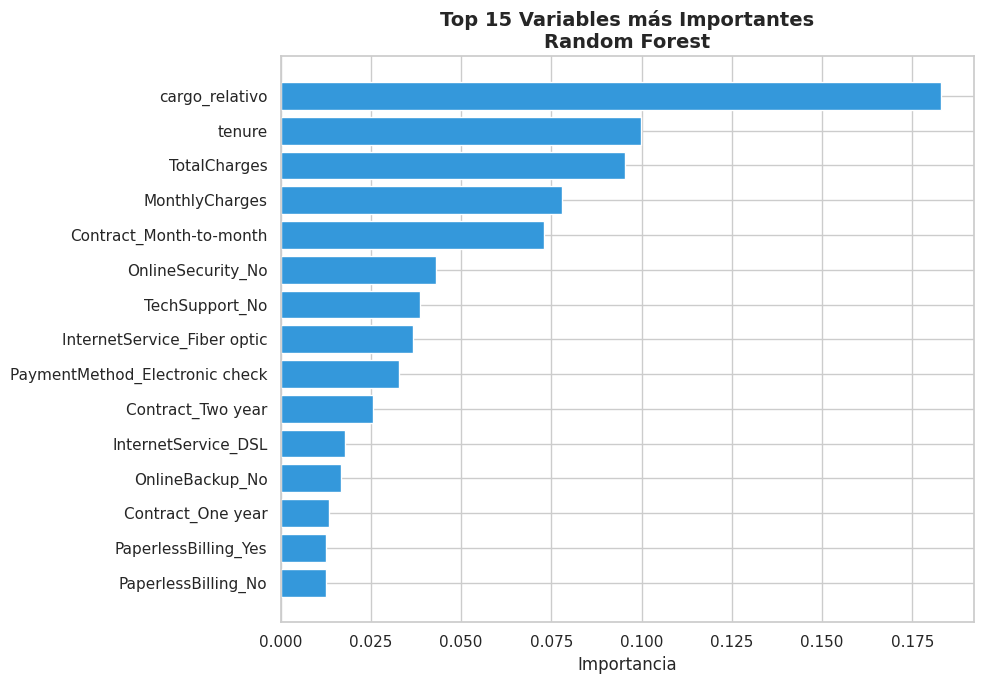

In [ ]:
# Obtenemos nombres de columnas después del preprocesamiento
ohe_features = grid_rf.best_estimator_['preprocessor']\
    .named_transformers_['cat']['onehot']\
    .get_feature_names_out(columnas_categoricas)

feature_names = columnas_numericas + list(ohe_features)

# Importancias del Random Forest
importancias = grid_rf.best_estimator_['classifier'].feature_importances_
indices = importancias.argsort()[-15:]

plt.figure(figsize=(10, 7))
plt.barh(range(15), importancias[indices], color='#3498db', edgecolor='white')
plt.yticks(range(15), [feature_names[i] for i in indices])
plt.title('Top 15 Variables más Importantes\nRandom Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Interpretación

Las variables más influyentes para predecir el churn son:

- **tenure (~0.14):** la antigüedad del cliente es el factor
  más determinante — los clientes nuevos tienen mucho mayor
  riesgo de abandonar

- **TotalCharges (~0.12):** relacionado directamente con tenure,
  confirma que los cargos acumulados reflejan el tiempo
  de permanencia del cliente

- **Contract_Month-to-month (~0.10):** los contratos mensuales
  son el tipo de contrato con mayor riesgo de churn,
  ya que no generan compromiso a largo plazo

- **MonthlyCharges (~0.09):** cargos mensuales altos aumentan
  la probabilidad de abandono

- **OnlineSecurity_No (~0.06):** los clientes sin servicio
  de seguridad online muestran mayor tendencia al churn

> 💡 Estos hallazgos sugieren que una estrategia efectiva
> de retención debería enfocarse en **clientes nuevos**,
> con **contratos mensuales** y **cargos elevados**.

## 8. Conclusiones e Insights

**Sobre las hipótesis de trabajo:**
- **H1 confirmada:** los clientes con menor antigüedad concentran
  la mayor proporción de churn, siendo `tenure` la variable
  con mayor capacidad predictiva según el modelo
- **H2 confirmada:** el tipo de contrato mes a mes es el segundo
  predictor más relevante, con una diferencia marcada respecto
  a contratos de uno o dos años
- **H3 respaldada:** los clientes con cargos mensuales más elevados
  presentan una mayor incidencia de churn dentro del
  conjunto analizado

**Recomendación de negocio:**
> 💡 Una estrategia de retención efectiva debería enfocarse
> en clientes nuevos con contratos mensuales y cargos elevados,
> interviniendo con ofertas personalizadas durante los primeros
> meses de relación con la empresa. El modelo desarrollado
> permite identificar ese segmento de riesgo con anticipación,
> habilitando decisiones basadas en evidencia.